In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

## Check correlation 

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

path = 'C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/data_panel/'

df_master = pd.read_csv(path + 'panel_master.csv')
print(df_master)

    geo nace_r2  real_wage  year  ai_adoption  spec_ict  training_ict  \
0    AT       C      26.74  2021        9.610     28.56         22.98   
1    AT       C      26.18  2022       10.960     28.37         25.60   
2    AT       C      26.07  2023       12.310     29.20         25.83   
3    AT       C      27.05  2024       22.710     30.02         26.06   
4    AT       F      22.43  2021        3.120      8.64          8.28   
..   ..     ...        ...   ...          ...       ...           ...   
531  SK       G       8.45  2024       11.650     15.19         19.87   
532  SK       J      15.69  2021       18.190     70.76         55.96   
533  SK       J      14.79  2022       19.905     71.88         53.54   
534  SK       J      14.48  2023       21.620     70.80         58.16   
535  SK       J      14.67  2024       29.190     69.72         62.79   

     productivity    FSI  share_high_skill  tert_edu  log_prod  
0       102250.14  55.82             36.58      31.8     1

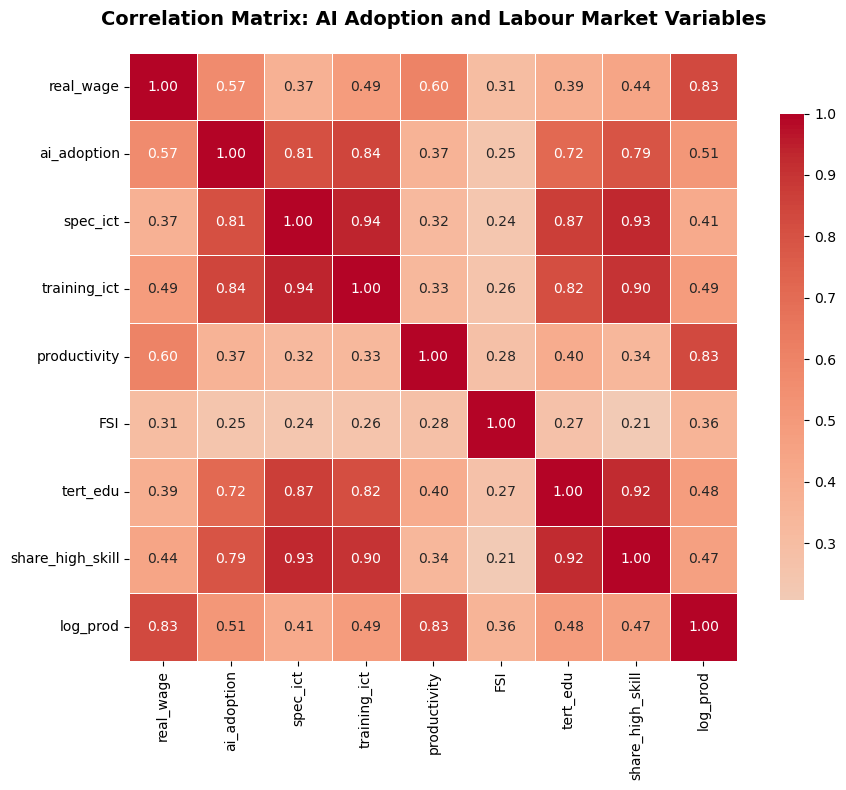

In [10]:
numeric_cols = [
    'real_wage', 
    'ai_adoption', 
    'spec_ict', 
    'training_ict', 
    'productivity',
    'FSI', 
    'tert_edu',
    'share_high_skill',
    'log_prod'
]

corr_matrix = df_master[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          
    fmt='.2f',            
    cmap='coolwarm',      
    center=0,             
    square=True,          
    linewidths=0.5,       
    cbar_kws={'shrink': 0.8}  
)

plt.title('Correlation Matrix: AI Adoption and Labour Market Variables', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Balanced panel

In [ ]:
df_master = pd.read_csv(path + 'panel_master.csv')
print(df_master)

    geo nace_r2  real_wage  year  ai_adoption  spec_ict  training_ict  \
0    AT       C      26.74  2021        9.610     28.56         22.98   
1    AT       C      26.18  2022       10.960     28.37         25.60   
2    AT       C      26.07  2023       12.310     29.20         25.83   
3    AT       C      27.05  2024       22.710     30.02         26.06   
4    AT       F      22.43  2021        3.120      8.64          8.28   
..   ..     ...        ...   ...          ...       ...           ...   
531  SK       G       8.45  2024       11.650     15.19         19.87   
532  SK       J      15.69  2021       18.190     70.76         55.96   
533  SK       J      14.79  2022       19.905     71.88         53.54   
534  SK       J      14.48  2023       21.620     70.80         58.16   
535  SK       J      14.67  2024       29.190     69.72         62.79   

     productivity    FSI  share_high_skill  log_prod  
0       102250.14  55.82             36.58     11.54  
1       10839

In [3]:
df_master['id'] = df_master['geo'] + '_' + df_master['nace_r2']
df_model = df_master.set_index(['id', 'year']).sort_index()

df_model['log_real_wage'] = np.log(df_model['real_wage'])
df_model['ai_x_ict'] = df_model['ai_adoption'] * df_model['spec_ict']


print(f"Observations: {len(df_model)}")
print(df_model.head())

Observations: 405
          geo nace_r2  real_wage  ai_adoption  spec_ict  training_ict  \
id   year                                                               
AT_C 2022  AT       C  26.183200        10.96    28.370         25.60   
     2023  AT       C  26.073620        12.31    29.195         25.83   
     2024  AT       C  27.047165        22.71    30.020         26.06   
AT_F 2022  AT       F  21.805567         3.70     9.030          6.91   
     2023  AT       F  20.398773         4.28     8.075          8.01   

           prodct_calc        FSI  share_high_skill   prod_lag  log_prod_lag  \
id   year                                                                      
AT_C 2022    99.583350  56.103620         37.320574  94.901027      4.552835   
     2023    97.676787  57.515861         38.711970  99.583350      4.600995   
     2024          NaN  57.656678         40.126825  97.676787      4.581664   
AT_F 2022    67.502141  21.448785         27.466433  64.316043      4.

In [4]:
# entity_effects=True - cross-sectional effect 
# time_effects=True - time fixed effect 
# without these variables will be just pooled OLS
# cluster_entity=True - calculates Clustered Standard Errors (treat the grouped observations (Austria-sector C) as a single cluster (group), not independently). Allow the errors within this group to be correlated

In [5]:
y = df_model['log_real_wage']

exog_vars = [
    'ai_adoption',       # Main Effect: AI
    'spec_ict',          # Main Effect: ICT Specialists
    'ai_x_ict',          # Interaction: AI * ICT
    # 'training_ict',      # Control: ICT Training
    'log_prod_lag',      # Control: Productivity (t-1)
    'FSI',               # Control: Firm Size
    'share_high_skill'   # Control: Human Capital
]

X = df_model[exog_vars]
X = sm.add_constant(X)

mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
res_panel_full = mod.fit(cov_type='clustered', cluster_entity=True)
print(res_panel_full)


                          PanelOLS Estimation Summary                           
Dep. Variable:          log_real_wage   R-squared:                        0.2073
Estimator:                   PanelOLS   R-squared (Between):              0.0515
No. Observations:                 405   R-squared (Within):               0.2036
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.0522
Time:                        09:15:46   Log-likelihood                    866.88
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      11.422
Entities:                         135   P-value                           0.0000
Avg Obs:                       3.0000   Distribution:                   F(6,262)
Min Obs:                       3.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             4.2855
                            

In [6]:
y = df_model['log_real_wage']

exog_vars = [
    'ai_adoption',       # Main Effect: AI
    'spec_ict',          # Main Effect: ICT Specialists
    'ai_x_ict',          # Interaction: AI * ICT
    # 'training_ict',      # Control: ICT Training
    'log_prod_lag',      # Control: Productivity (t-1)
    'FSI',               # Control: Firm Size
    'share_high_skill'   # Control: Human Capital
]

X = df_model[exog_vars]
X = sm.add_constant(X)

mod = PanelOLS(y, X, entity_effects=True)
res_panel_cs_FE = mod.fit(cov_type='clustered', cluster_entity=True)
print(res_panel_cs_FE)

                          PanelOLS Estimation Summary                           
Dep. Variable:          log_real_wage   R-squared:                        0.3448
Estimator:                   PanelOLS   R-squared (Between):              0.1875
No. Observations:                 405   R-squared (Within):               0.3448
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.1882
Time:                        09:15:46   Log-likelihood                    838.68
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      23.150
Entities:                         135   P-value                           0.0000
Avg Obs:                       3.0000   Distribution:                   F(6,264)
Min Obs:                       3.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             17.530
                            

In [7]:
from linearmodels.panel import PooledOLS

# Pooled OLS does not use Entity Effects
# It treats every row as an independent observation
mod_pool = PooledOLS(y, X)
res_pool = mod_pool.fit(cov_type='clustered', cluster_entity=True)
print(res_pool)

                          PooledOLS Estimation Summary                          
Dep. Variable:          log_real_wage   R-squared:                        0.7916
Estimator:                  PooledOLS   R-squared (Between):              0.8185
No. Observations:                 405   R-squared (Within):              -5.3859
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.7916
Time:                        09:15:46   Log-likelihood                   -31.022
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      252.02
Entities:                         135   P-value                           0.0000
Avg Obs:                       3.0000   Distribution:                   F(6,398)
Min Obs:                       3.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             81.552
                            

In [8]:
from linearmodels.panel import BetweenOLS, FirstDifferenceOLS, RandomEffects
import pandas as pd
import statsmodels.api as sm

mod_be = BetweenOLS(y, X)
res_be = mod_be.fit()
print(res_be)

                         BetweenOLS Estimation Summary                          
Dep. Variable:          log_real_wage   R-squared:                        0.8354
Estimator:                 BetweenOLS   R-squared (Between):              0.8354
No. Observations:                 135   R-squared (Within):              -17.105
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.7576
Time:                        09:15:46   Log-likelihood                    5.8633
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      108.27
Entities:                         135   P-value                           0.0000
Avg Obs:                       3.0000   Distribution:                   F(6,128)
Min Obs:                       3.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             108.27
                            

In [9]:
# "Weighted average of Fixed Effects and Between Effects."
# Best model if your unobserved country traits are NOT correlated with AI.
mod_re = RandomEffects(y, X)
res_re = mod_re.fit()
print(res_re)


                        RandomEffects Estimation Summary                        
Dep. Variable:          log_real_wage   R-squared:                        0.4416
Estimator:              RandomEffects   R-squared (Between):              0.5843
No. Observations:                 405   R-squared (Within):               0.1662
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.5825
Time:                        09:15:46   Log-likelihood                    653.39
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      52.465
Entities:                         135   P-value                           0.0000
Avg Obs:                       3.0000   Distribution:                   F(6,398)
Min Obs:                       3.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             52.465
                            

In [10]:
# Similar to Fixed Effects, often handles trends better.
X_fd = X.drop(columns=['const'])
mod_fd = FirstDifferenceOLS(y, X_fd)
res_fd = mod_fd.fit()
print(res_fd)

                     FirstDifferenceOLS Estimation Summary                      
Dep. Variable:          log_real_wage   R-squared:                        0.2703
Estimator:         FirstDifferenceOLS   R-squared (Between):              0.1092
No. Observations:                 270   R-squared (Within):               0.3066
Date:                Mon, Jan 19 2026   R-squared (Overall):              0.1092
Time:                        09:15:46   Log-likelihood                    455.73
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      16.301
Entities:                         135   P-value                           0.0000
Avg Obs:                       3.0000   Distribution:                   F(6,264)
Min Obs:                       3.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             16.301
                            

In [11]:
from linearmodels.panel import compare

comparison = {
    'Pooled OLS': res_pool,
    'Between': res_be,
    'Random Effects': res_re,
    'Fixed Effects full': res_panel_full, 
    'Fixed Effect cross-sect' : res_panel_cs_FE,
    'First Diff': res_fd
}

summary_table = compare(comparison)

print(summary_table)

                                                                Model Comparison                                                               
                               Pooled OLS           Between    Random Effects Fixed Effects full Fixed Effect cross-sect             First Diff
-----------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable               log_real_wage     log_real_wage     log_real_wage      log_real_wage           log_real_wage          log_real_wage
Estimator                       PooledOLS        BetweenOLS     RandomEffects           PanelOLS                PanelOLS     FirstDifferenceOLS
No. Observations                      405               135               405                405                     405                    270
Cov. Est.                       Clustered        Unadjusted        Unadjusted          Clustered               Clustered             Una

In [12]:
import statsmodels.stats.diagnostic as smd
from scipy import stats

# Model selection test (WALD TEST)
# https://bashtage.github.io/linearmodels/panel/panel/linearmodels.panel.results.PanelEffectsResults.f_pooled.html
# 1. F-Test for Fixed Effects (Pooled OLS vs. Fixed Effects)
# H0: Pooled OLS is better (Entity effects are zero)
# H1: Fixed Effects is bette

print(f"1. F-Test for Entity Effects (Pooled vs FE):")
print(f"   F-Stat: {res_panel_full.f_pooled.stat:.4f}")
print(f"   P-Value: {res_panel_full.f_pooled.pval:.4f}")
if res_panel_full.f_pooled.pval < 0.05:
    print("   -> Result: REJECT H0. Use Fixed Effects over Pooled OLS.")
else:
    print("   -> Result: ACCEPT H0. Pooled OLS is sufficient.")



1. F-Test for Entity Effects (Pooled vs FE):
   F-Stat: 160.4264
   P-Value: 0.0000
   -> Result: REJECT H0. Use Fixed Effects over Pooled OLS.


In [13]:
# 2. Breusch-Pagan LM Test (Pooled OLS vs. Random Effects)
# H0: Variance of random effects is 0 (Pooled OLS is fine)
# H1: Variance > 0 (Random Effects are needed)
# We calculate this manually using residuals from Pooled OLS
resid_pool = res_pool.resids
n = len(df_model.index.get_level_values(0).unique()) # Entities
T = len(df_model.index.get_level_values(1).unique()) # Time periods
# Calculation
lm_stat = (n * T) / (2 * (T - 1)) * (
    (resid_pool.groupby(level=0).sum() ** 2).sum() / (resid_pool ** 2).sum() - 1
) ** 2
lm_pval = 1 - stats.chi2.cdf(lm_stat, df=1)

print(f"\n2. Breusch-Pagan LM Test (Pooled vs Random Effects):")
print(f"   LM Stat: {lm_stat:.4f}")
print(f"   P-Value: {lm_pval:.4f}")
if lm_pval < 0.05:
    print("   -> Result: REJECT H0. Random Effects is better than Pooled.")
else:
    print("   -> Result: ACCEPT H0. Pooled OLS is sufficient.")


2. Breusch-Pagan LM Test (Pooled vs Random Effects):
   LM Stat: 259.5978
   P-Value: 0.0000
   -> Result: REJECT H0. Random Effects is better than Pooled.


In [14]:
# 3. Hausman Test (Fixed Effects vs. Random Effects)
# H0: Random Effects is consistent (Use RE - it's more efficient)
# H1: Random Effects is biased (Use FE - it's safer)
b_fe = res_panel_full.params
b_re = res_re.params
cov_fe = res_panel_full.cov
cov_re = res_re.cov
# Calculate Chi-Square
diff = b_fe - b_re
# Note: Usually we drop the constant for Hausman as FE doesn't estimate it the same way
diff = diff.drop('const')
cov_diff = cov_fe.loc[diff.index, diff.index] - cov_re.loc[diff.index, diff.index]
hausman_stat = diff.dot(np.linalg.inv(cov_diff)).dot(diff)
hausman_pval = 1 - stats.chi2.cdf(hausman_stat, df=len(diff))

print(f"\n3. Hausman Test (FE vs RE):")
print(f"   Chi2 Stat: {hausman_stat:.4f}")
print(f"   P-Value: {hausman_pval:.4f}")
if hausman_pval < 0.05:
    print("   -> Result: REJECT H0. Use Fixed Effects (RE is biased).")
else:
    print("   -> Result: ACCEPT H0. Use Random Effects (It is safe & efficient).")


3. Hausman Test (FE vs RE):
   Chi2 Stat: 42.5552
   P-Value: 0.0000
   -> Result: REJECT H0. Use Fixed Effects (RE is biased).


In [15]:
# 4. Heteroskedasticity Tests (White & Breusch-Pagan)
# We run these on the POOLED residuals (standard approach)
# H0: Homoskedasticity (Variance is constant) -> Good
# H1: Heteroskedasticity (Variance changes) -> Bad (Need Robust Errors)
bp_test = smd.het_breuschpagan(res_panel_full.resids, res_panel_full.model.exog.dataframe)
white_test = smd.het_white(res_panel_full.resids, res_panel_full.model.exog.dataframe)

print(f"4. Heteroskedasticity Tests:")
print(f"   Breusch-Pagan P-Value: {bp_test[1]:.4f}")
print(f"   White Test P-Value:    {white_test[1]:.4f}")
if bp_test[1] < 0.05:
    print("   -> Result: HETEROSKEDASTICITY DETECTED. (You MUST use cov_type='clustered')")
else:
    print("   -> Result: Homoskedasticity. (Data is clean).")

4. Heteroskedasticity Tests:
   Breusch-Pagan P-Value: 0.0421
   White Test P-Value:    0.0185
   -> Result: HETEROSKEDASTICITY DETECTED. (You MUST use cov_type='clustered')


In [16]:
# 5. Serial Correlation (Breusch-Godfrey)
# H0: No Serial Correlation
# H1: Serial Correlation exists
# Note: We restrict lags to 1 because you only have 3 years of data
bg_test = smd.acorr_breusch_godfrey(res_panel_full, nlags=1)

print(f"\n5. Serial Correlation (Breusch-Godfrey):")
print(f"   P-Value: {bg_test[1]:.4f}")
if bg_test[1] < 0.05:
    print("   -> Result: SERIAL CORRELATION DETECTED. (Use Clustered Errors).")
else:
    print("   -> Result: No Serial Correlation.")

AttributeError: 'PanelEffectsResults' object has no attribute 'resid'

In [17]:
# 6. Chow Test (Test for Poolability)
# This is automatically calculated in the PanelOLS summary!
# It tests if the slopes are different for every entity.
# linearmodels calls this "F-test for Poolability"
print(f"6. Chow Test (Poolability):")
# We access the F-statistic directly from the results object
print(f"   F-Stat: {res_panel_full.f_pooled.stat:.4f}")
print(f"   P-Value: {res_panel_full.f_pooled.pval:.4f}")
if res_panel_full.f_pooled.pval < 0.05:
    print("   -> Result: Coefficients are NOT stable across entities. (Panel models are necessary).")


6. Chow Test (Poolability):
   F-Stat: 160.4264
   P-Value: 0.0000
   -> Result: Coefficients are NOT stable across entities. (Panel models are necessary).


In [ ]:
# 7. Wald Test (Joint Significance)
# Example: Does 'training_ict' AND 'share_high_skill' jointly equal zero?
# Use this to test if your Control Variables matter as a group.
formula = 'training_ict = 0, share_high_skill = 0'
# Note: If you removed these variables, change the formula to 'spec_ict = 0, ai_adoption = 0'
try:
    wald_res = res_panel_full.wald_test(formula=formula)
    print(f"\n7. Wald Test (Joint Significance of Controls):")
    print(f"   Stat: {wald_res.stat:.4f}, P-Value: {wald_res.pval:.4f}")
except:
    print("\n7. Wald Test: Skipped (Variables not in model).")


7. Wald Test: Skipped (Variables not in model).


In [ ]:
# Calculate the variance
variance_data = df_model['ai_adoption']
mean_total = variance_data.mean()

# Between Variance (Variation across countries)
between_var = df_model.groupby('id')['ai_adoption'].mean().var()

# Within Variance (Variation over time within a country)
within_var = (df_model['ai_adoption'] - df_model.groupby('id')['ai_adoption'].transform('mean')).var()

print(f"Variance BETWEEN Sectors (Structure): {between_var:.4f}")
print(f"Variance WITHIN Sectors (Time):       {within_var:.4f}")

ratio = between_var / within_var
print(f"Ratio (Between / Within):             {ratio:.2f}")

Variance BETWEEN Sectors (Structure): 127.1059
Variance WITHIN Sectors (Time):       22.1191
Ratio (Between / Within):             5.75
